# 05 — Top non-government, non-party advocacy spenders

**The question**: among advertisers that are *neither government nor a registered party/candidate*, who spent the most on political-adjacent FB ads around the May 2022 federal election, and how do their spending patterns differ across the campaign window?

**Why exclude parties and candidates**: party central offices and candidate ads dominate raw spend totals (Australian Labor Party + UAP alone account for ~$5M pre-election spend). Their election-only behaviour is expected and uninteresting. The structurally interesting question is who's *in the advocacy ecosystem alongside them* — NGO campaigns, PAC-style election funders, single-issue advocacy groups — and how that ecosystem's spending pattern compares.

**Headline deliverable**: ranked list of the top 20 non-government, non-party advocacy spenders, with pre/post-election spend, persistence ratios, and topic mix.

**Input corpus**: v3 parquet from [04_topic_join.ipynb](04_topic_join.ipynb), filtered down to `match_type IS NULL` (i.e. only the LDA-classified advocacy residual — no candidate, no party_org, no government).

**Window**: 6 months before to 6 months after the 21 May 2022 election.

## 1. Setup

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum as spark_sum, count as spark_count, countDistinct,
    when, lit, date_trunc, desc, mode, broadcast,
)
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

spark = SparkSession.builder \
    .appName('FB_API_election_spenders') \
    .config('spark.sql.parquet.output.committer.class',
            'org.apache.parquet.hadoop.ParquetOutputCommitter') \
    .config('mapreduce.fileoutputcommitter.algorithm.version', '2') \
    .getOrCreate()

print('Master:', spark.sparkContext.master)
print('Spark version:', spark.version)

Master: yarn
Spark version: 3.5.0


26/05/13 10:51:38 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [2]:
V3_PATH = '/user/s3348393/main/preprocessing/v3/parquet'

ELECTION_DATE = pd.Timestamp('2022-05-21')
WINDOW_START  = pd.Timestamp('2021-11-21')
WINDOW_END    = pd.Timestamp('2022-11-21')

# Consistent palette across every chart in this notebook so the same advertiser
# type reads the same colour everywhere.
GROUP_COLORS = {
    'candidate':           '#1f77b4',   # blue
    'party_org':           '#ff7f0e',   # orange
    'climate':             '#2ca02c',   # green
    'humanitarian_rights': '#d62728',   # red
    'political_advocacy':  '#9467bd',   # purple
    'cost_of_living':      '#8c564b',   # brown
}

## 2. Load v3 and restrict to advocacy

Two filters applied at load:

1. **`match_type IS NULL`** — drop candidate and party_org. We're explicitly looking at the advocacy ecosystem only.
2. **Tag a `group` column** = LDA `category` (`climate`, `humanitarian_rights`, `political_advocacy`, `cost_of_living`).

Cache the result — every subsequent cell scans it.

In [3]:
v3 = spark.read.parquet(V3_PATH)

# Drop candidate and party_org — focus on advocacy ecosystem only.
v3 = v3.filter(col('match_type').isNull())

# Use category as the group label (climate / humanitarian_rights / political_advocacy / cost_of_living).
v3 = v3.withColumn('group', col('category'))

# Tag pre/post election by ad creation date.
v3 = v3.withColumn(
    'period',
    when(col('ad_creation_date') < lit('2022-05-21'), 'pre')
    .otherwise('post')
)

v3 = v3.cache()
print(f'Advocacy ads in v3: {v3.count():,}')
print('\nGroup distribution:')
v3.groupBy('group').agg(
    spark_count('*').alias('ads'),
    spark_sum('spend_mid').alias('total_spend'),
).orderBy(desc('total_spend')).show(truncate=False)

26/05/13 10:51:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Advocacy ads in v3: 93,938

Group distribution:
+-------------------+-----+------------+
|group              |ads  |total_spend |
+-------------------+-----+------------+
|political_advocacy |42603|1.01355485E7|
|climate            |32093|8196403.5   |
|humanitarian_rights|17075|5693762.5   |
|cost_of_living     |2167 |600066.5    |
+-------------------+-----+------------+



## 3. Top 20 election spenders (table)

Rank bylines by total spend during the **pre-election** window (Nov 2021 – May 2022) — this is the campaign-period money. For each, also compute post-election spend and a persistence ratio.

Persistence = `post_spend / pre_spend`. Bands:
- `persistence < 0.2` → **election-only** (PAC-style — barely visible after election)
- `0.2 ≤ persistence ≤ 0.8` → **transitional**
- `persistence > 0.8` → **ongoing advocate** (steady-state advertiser)

In [4]:
# Per-byline pre and post spend totals.
byline_spend = (v3
    .filter(col('spend_mid').isNotNull() & col('bylines').isNotNull())
    .groupBy('bylines')
    .pivot('period', ['pre', 'post'])
    .agg(spark_sum('spend_mid'))
).na.fill(0)

# Modal group per byline — collect counts in Spark, pick max in pandas.
group_per_byline = (v3.filter(col('bylines').isNotNull())
    .groupBy('bylines', 'group').count()
    .toPandas())

primary_group = (group_per_byline
    .sort_values(['bylines', 'count'], ascending=[True, False])
    .drop_duplicates('bylines', keep='first')
    [['bylines', 'group']])

# Bring spend to pandas, merge group, compute persistence, sort.
spend_pdf = byline_spend.toPandas()
spend_pdf.columns = ['bylines', 'pre_spend', 'post_spend']
spend_pdf = spend_pdf.merge(primary_group, on='bylines', how='left')
spend_pdf['total_spend'] = spend_pdf['pre_spend'] + spend_pdf['post_spend']
spend_pdf['persistence'] = spend_pdf['post_spend'] / spend_pdf['pre_spend'].replace(0, pd.NA)
spend_pdf['band'] = pd.cut(
    spend_pdf['persistence'].fillna(0),
    bins=[-0.001, 0.2, 0.8, float('inf')],
    labels=['election_only', 'transitional', 'ongoing']
)

top20 = spend_pdf.sort_values('pre_spend', ascending=False).head(20).reset_index(drop=True)
top20[['bylines', 'group', 'pre_spend', 'post_spend', 'persistence', 'band']]

,bylines,group,pre_spend,post_spend,persistence,band
0,Greenpeace Australia Pacific,climate,808323.0,742846.5,0.918997,ongoing
1,Amnesty International Australia,political_advocacy,704031.5,148587.5,0.211052,transitional
2,Solutions for Australia,climate,588535.5,66805.0,0.113511,election_only
3,Climate 200,political_advocacy,509706.5,118518.0,0.232522,transitional
4,Shell,political_advocacy,425398.5,0.0,0.0,election_only
5,Australian Conservation Foundation,climate,388525.0,257467.5,0.662679,transitional
6,Thrive By Five,humanitarian_rights,379709.0,232341.0,0.611892,transitional
7,The Pharmacy Guild of Australia,cost_of_living,335291.5,0.0,0.0,election_only
8,Australia for UNHCR,humanitarian_rights,331389.0,182949.5,0.552069,transitional
9,Smart Voting,political_advocacy,303371.5,0.0,0.0,election_only


## 4. Cumulative spend over time (recommended headline chart)

Each top-20 byline's running total of spend through the window. The shape encodes persistence directly:

- **Election-only** advertisers: steep climb pre-election → flat horizontal line after. The curve "elbows" at the election date.
- **Ongoing** advocates: roughly constant slope across the year.

Curves coloured by `group`. End-of-line labels give per-byline identity (lines naturally separate by total spend so labels rarely collide). Election-day vertical line for orientation.

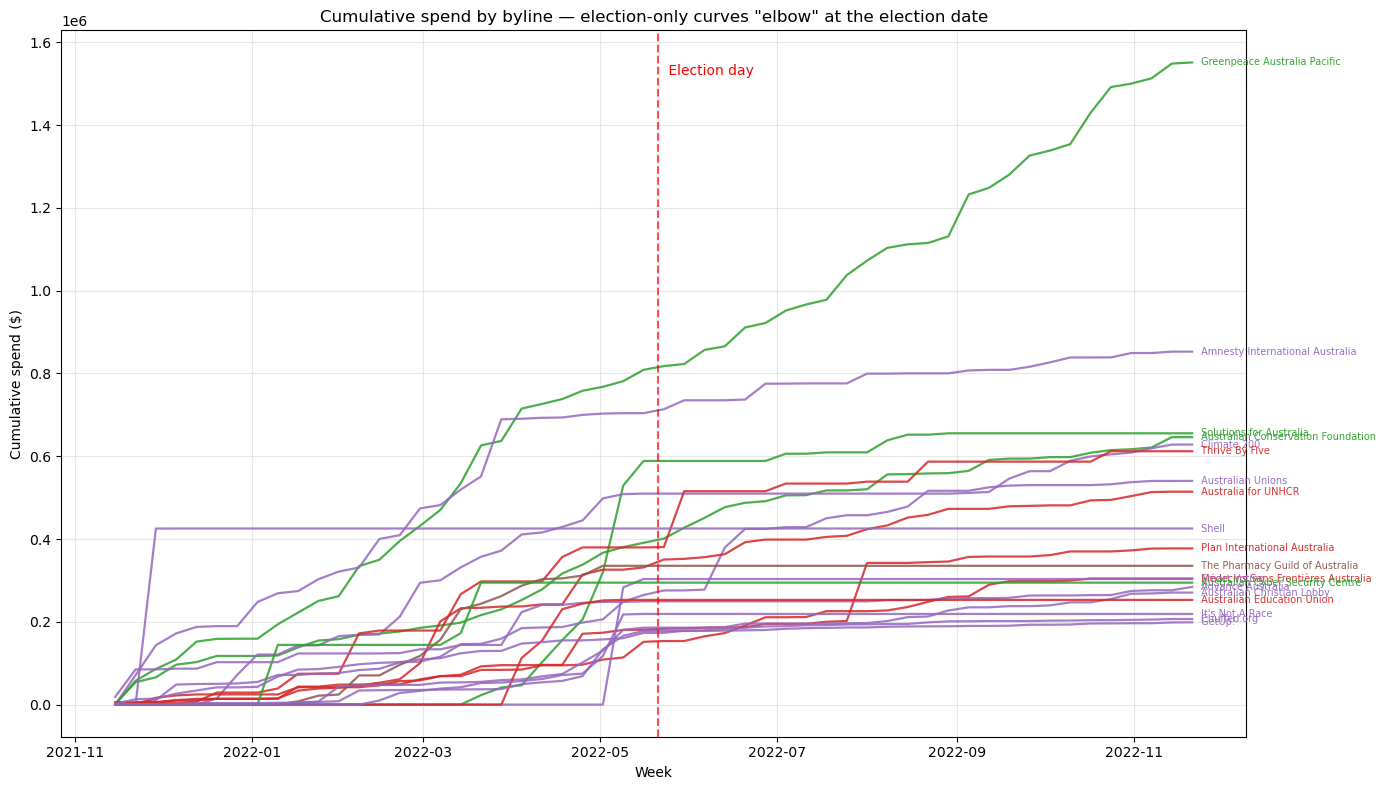

In [5]:
top20_bylines = top20['bylines'].tolist()

# Weekly aggregation per byline — cached on driver as pandas, reused by every chart below.
weekly = (v3
    .filter(col('bylines').isin(top20_bylines) & col('spend_mid').isNotNull())
    .withColumn('week', date_trunc('week', 'ad_creation_date'))
    .groupBy('week', 'bylines', 'group')
    .agg(spark_sum('spend_mid').alias('spend'))
    .orderBy('week')
    .toPandas())

# Pivot to byline × week (used by stacked/cumulative/heatmap charts below).
pivot = weekly.pivot_table(index='week', columns='bylines', values='spend', aggfunc='sum').fillna(0)
col_order = pivot.sum().sort_values(ascending=False).index.tolist()
pivot = pivot[col_order]
byline_group = dict(zip(top20['bylines'], top20['group']))

# Cumulative spend per byline — the elbow tells the story.
cumulative = pivot.cumsum()

fig, ax = plt.subplots(figsize=(14, 8))
for byline in cumulative.columns:
    grp = byline_group.get(byline, 'unknown')
    color = GROUP_COLORS.get(grp, '#777777')
    ax.plot(cumulative.index, cumulative[byline],
            color=color, alpha=0.85, linewidth=1.6)
    # End-of-line label
    end_val = cumulative[byline].iloc[-1]
    ax.text(cumulative.index[-1] + pd.Timedelta(days=2),
            end_val, ' ' + byline[:35],
            fontsize=7, va='center', color=color, alpha=0.95)

ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.7, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Cumulative spend by byline — election-only curves "elbow" at the election date')
ax.set_xlabel('Week')
ax.set_ylabel('Cumulative spend ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4b. Enrich top 20 with band classifier (persistence + centroid)

**Smoothing**: the raw weekly series is bursty — many advertisers buy media in 1–2 week pulses separated by zeros, which leverages persistence, centroid and EC heavily on isolated spikes. Before computing summary statistics we apply a **4-week centred rolling mean** to each byline's weekly series (`spend_smooth`). The raw weekly series is still used for plotting (small multiples, stacked area) so campaign shape stays visible; only the *summary metrics* run on the smoothed series.

Binary pre/post persistence has one further failure mode — *off-campaign one-offs* like Shell, whose December 2021 spend gives persistence ≈ 0 even though they're not election-driven. Fix: combine persistence with the centroid (weighted-mean week-from-election) of each advertiser's spending. A persistence-low advertiser whose centroid is way outside the campaign window gets re-classified as off-campaign.

**Four bands** (all computed on smoothed spend):

| Band | Rule | Interpretation |
|---|---|---|
| `off_campaign` | `persistence < 0.3` **AND** `|centroid_weeks| > 16` | Spent before/after the campaign cycle, not in it (Shell) |
| `election_only` | `persistence < 0.3` (and centroid within 16w) | Spent then stopped at election |
| `ongoing` | `persistence > 0.8` | Spent at roughly similar rates pre and post |
| `transitional` | else | Tapered after election |

**Two supplementary metrics carried alongside** (also smoothed):

- **Election Concentration (EC) index**: triangular-weighted concentration of spend around election day. Range 0–1 with 0.5 as the uniform baseline.
- **Centroid (weeks-from-election)**: weighted-mean week of spending. Negative = pre-election; positive = post-election; near 0 = election week.

In [ ]:
import numpy as np

HALF_WIDTH_WEEKS = 26     # triangle window: 0 at edges, 1 at election
CENTROID_WINDOW  = 16     # weeks; |centroid| > this → off-campaign
PERSIST_LOW      = 0.30
PERSIST_HIGH     = 0.80
SMOOTH_WINDOW    = 4      # 4-week centred rolling mean — kills 1-week burst artefacts

# --- Smooth each byline's weekly series before computing summary metrics ---
# Rebuild on a complete week index per byline so the rolling window has
# proper zero-padding through quiet weeks instead of skipping them.
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
bylines_in_weekly = weekly['bylines'].unique()
full_index = pd.MultiIndex.from_product([bylines_in_weekly, all_weeks],
                                         names=['bylines', 'week'])
weekly = (weekly.set_index(['bylines', 'week'])
                .reindex(full_index, fill_value=0.0)
                .reset_index())

# Re-attach group (lost in the reindex fill).
weekly = weekly.drop(columns=['group']).merge(
    top20[['bylines', 'group']], on='bylines', how='left')

# 4-week centred rolling mean per byline. min_periods=1 so edge weeks aren't NaN.
weekly['spend_smooth'] = (weekly.groupby('bylines')['spend']
    .transform(lambda s: s.rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()))

# Triangle weights for the EC index.
weekly['weeks_from_election'] = (weekly['week'] - ELECTION_DATE).dt.days / 7
weekly['weight'] = np.clip(
    1.0 - np.abs(weekly['weeks_from_election']) / HALF_WIDTH_WEEKS,
    a_min=0.0, a_max=None,
)
weekly['weighted_spend_smooth'] = weekly['weight'] * weekly['spend_smooth']

# --- Recompute persistence, EC, centroid from the smoothed series ---
def _summary(x):
    total = x['spend_smooth'].sum()
    if total <= 0:
        return pd.Series({'pre_spend_s': 0.0, 'post_spend_s': 0.0,
                          'ec_index': 0.0, 'centroid_weeks': 0.0})
    pre = x.loc[x['week'] < ELECTION_DATE, 'spend_smooth'].sum()
    post = x.loc[x['week'] >= ELECTION_DATE, 'spend_smooth'].sum()
    return pd.Series({
        'pre_spend_s':    pre,
        'post_spend_s':   post,
        'ec_index':       x['weighted_spend_smooth'].sum() / total,
        'centroid_weeks': (x['weeks_from_election'] * x['spend_smooth']).sum() / total,
    })

smoothed = weekly.groupby('bylines').apply(_summary).reset_index()
smoothed['persistence'] = smoothed['post_spend_s'] / smoothed['pre_spend_s'].replace(0, pd.NA)

# Drop the raw persistence / ec / centroid (from cell 7) and replace with smoothed.
for c in ('persistence', 'ec_index', 'centroid_weeks', 'band'):
    if c in top20.columns:
        top20 = top20.drop(columns=[c])
top20 = top20.merge(
    smoothed[['bylines', 'persistence', 'ec_index', 'centroid_weeks']],
    on='bylines', how='left',
)

# Combined band classifier — smoothed persistence as primary, centroid as off-campaign override.
def _classify(row):
    p = row['persistence'] if pd.notna(row['persistence']) else 0.0
    c = abs(row['centroid_weeks']) if pd.notna(row['centroid_weeks']) else 0.0
    if p < PERSIST_LOW and c > CENTROID_WINDOW:
        return 'off_campaign'
    if p < PERSIST_LOW:
        return 'election_only'
    if p > PERSIST_HIGH:
        return 'ongoing'
    return 'transitional'

top20['band'] = top20.apply(_classify, axis=1)
top20['band'] = pd.Categorical(
    top20['band'],
    categories=['election_only', 'transitional', 'ongoing', 'off_campaign'],
    ordered=True,
)

display_cols = ['bylines', 'group', 'pre_spend', 'post_spend',
                'persistence', 'ec_index', 'centroid_weeks', 'band']
top20.sort_values(['band', 'total_spend'], ascending=[True, False])[display_cols]

## 5. Stacked area — absolute weekly spend

Same data, stacked by byline. Each byline gets a distinct colour (tab20 palette) since colour-by-group caused repeated colours and was unreadable. Top edge of the stack = total weekly spend across the top 20.

Best for showing *when total advocacy spending happened* and the relative composition. Still bursty week-to-week, but the aggregate envelope shows the election-period concentration clearly.

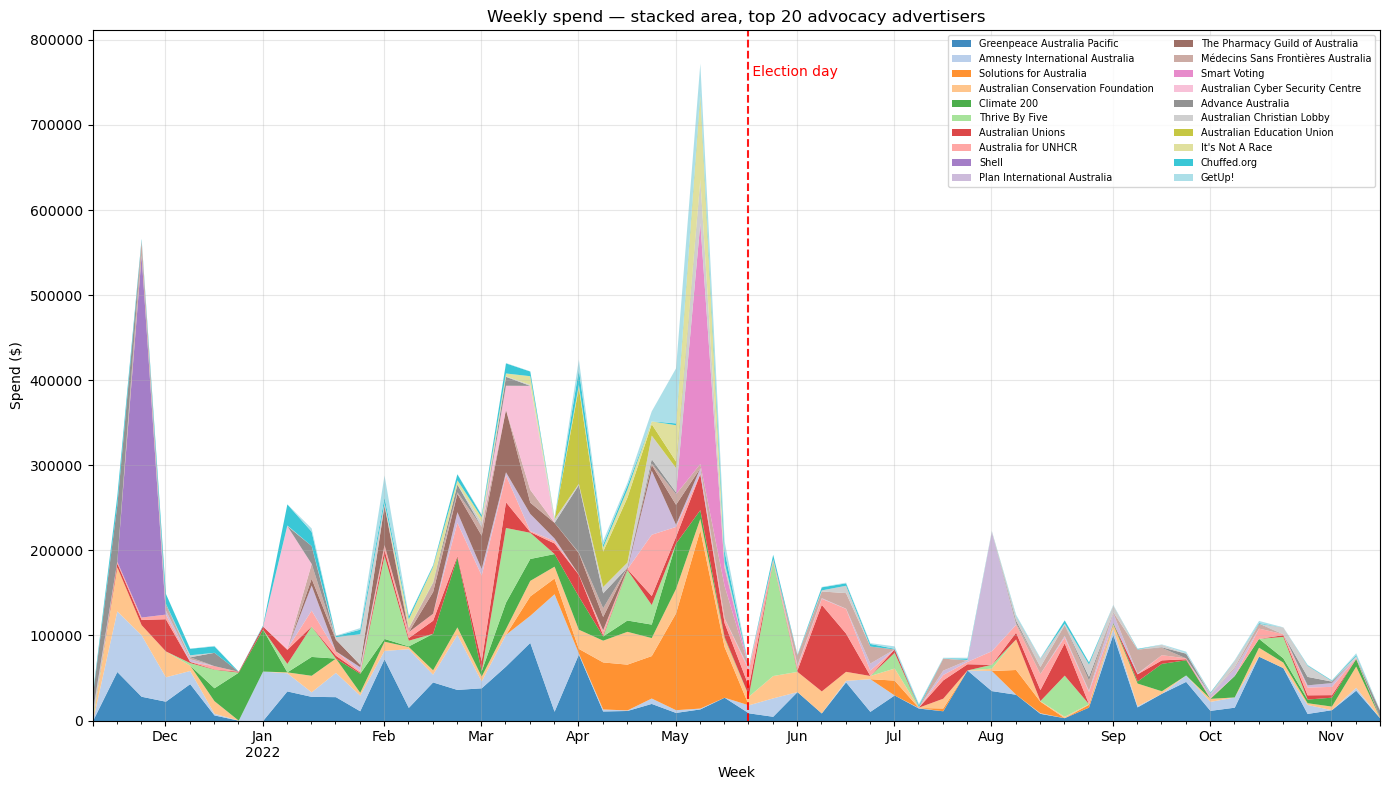

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
pivot.plot.area(ax=ax, alpha=0.85, linewidth=0, colormap='tab20')
ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.9, linewidth=1.5)
ax.text(ELECTION_DATE + pd.Timedelta(days=2), ax.get_ylim()[1] * 0.95,
        ' Election day', color='red', va='top')
ax.set_title('Weekly spend — stacked area, top 20 advocacy advertisers')
ax.set_ylabel('Spend ($)')
ax.set_xlabel('Week')
ax.legend(loc='upper right', fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Small multiples — grouped by band

Each top-20 advertiser gets its own panel, **grouped into four figures** by band (`election_only` / `transitional` / `ongoing` / `off_campaign`). Shared x-axis across all panels in a band (full Nov 2021 → Nov 2022 window) so timing is directly comparable. Each panel has its own y-axis (no `sharey`) so small-budget advertisers are visible.

Within each figure, panels are sorted by total spend descending. Panel title shows `(group, total spend, EC)` for context. Coloured by primary `group`.

In [ ]:
import math

# Full time window for sharex.
x_min = weekly['week'].min()
x_max = weekly['week'].max()

for band_name in ['election_only', 'transitional', 'ongoing', 'off_campaign']:
    band_data = top20[top20['band'] == band_name].sort_values('total_spend', ascending=False).reset_index(drop=True)
    n = len(band_data)
    if n == 0:
        print(f'No advertisers in band "{band_name}".\n')
        continue

    ncols = min(4, n)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5 * nrows),
                             squeeze=False, sharex=True, sharey=False)
    axes = axes.flatten()

    for i, row in band_data.iterrows():
        ax = axes[i]
        byline = row['bylines']
        grp = row['group']
        color = GROUP_COLORS.get(grp, '#777777')
        sub = weekly[weekly['bylines'] == byline].sort_values('week')
        ax.plot(sub['week'], sub['spend'], color=color, linewidth=1.3)
        ax.fill_between(sub['week'], sub['spend'], color=color, alpha=0.3)
        ax.axvline(ELECTION_DATE, linestyle='--', color='red', alpha=0.5)
        ax.set_title(f'{byline[:32]}\n({grp}, ${row["total_spend"]:,.0f}, EC={row["ec_index"]:.2f})', fontsize=8)
        ax.tick_params(axis='x', rotation=45, labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.grid(alpha=0.3)
        ax.set_xlim(x_min, x_max)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Weekly spend — {band_name} band ({n} advertisers)', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()

## 7. Temporal-pattern quadrant — spend imbalance × centroid

A single scatter with symmetric ±1 axes centred on the origin (perfectly balanced, election-week advertiser).

**X axis — spend imbalance**: `(post − pre) / (post + pre)`. Range −1 to +1.
- **Left** (x → −1): all spending pre-election → election-only behaviour.
- **Middle** (x ≈ 0): balanced pre/post → ongoing behaviour.
- **Right** (x → +1): all spending post-election → post-only behaviour.

**Y axis — centroid timing**: `−centroid_weeks / 26`. Range roughly −1 to +1.
- **Top** (y → +1): spending centroid sits well before election day → pre-election timing.
- **Middle** (y ≈ 0): centroid on/near election week.
- **Bottom** (y → −1): centroid post-election.

**Encoding**:
- Bubble size: `log(total_spend)` — biggest spenders are visually obvious.
- Bubble colour: band (election_only / transitional / ongoing / off_campaign).
- Quadrant labels in corners describe what the quadrant means semantically.

Most data will populate the **upper-left half** (heavy pre-election spending + pre-election centroid) — that's the structurally common pattern for election-aligned advocacy. The bottom-right corner (post-only post-centroid) and bottom-left (pre-bias post-centroid) are mostly empty in this corpus.

**Reading the chart**:
- **Top-left corner**: Shell (off_campaign) — heavy pre-bias AND centroid way before election.
- **Centre-left** (x ≈ −1, y ≈ 0): Smart Voting, Pharmacy Guild, AEU, Solutions for Australia, GetUp! — election-only with tight centroid.
- **Origin cluster**: Greenpeace, Australian Unions, MSF, Plan International — balanced + on-election centroid (ongoing).
- **Lower-middle region**: Australian Christian Lobby — slight post-centroid + moderate pre-bias.

In [ ]:
# Temporal-pattern quadrant — spend imbalance (x) × centroid timing (y), both ±1.

BAND_COLORS = {
    'election_only':   '#1f77b4',   # blue
    'transitional':    '#ff7f0e',   # orange
    'ongoing':         '#2ca02c',   # green
    'off_campaign':    '#d62728',   # red
}

# Axes — signed, normalised to ±1.
total = (top20['pre_spend'] + top20['post_spend']).replace(0, 1)
top20['x_imbalance'] = (top20['post_spend'] - top20['pre_spend']) / total
top20['y_centroid']  = (-top20['centroid_weeks'] / 26).clip(-1, 1)   # +ve = pre, −ve = post

fig, ax = plt.subplots(figsize=(12, 10))

# Quadrant cross at origin.
ax.axhline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)
ax.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)

# Bubbles — area ∝ total spend (linear scaling for max visual differentiation).
SPEND_AREA_DIVISOR = 2000
sizes = top20['total_spend'] / SPEND_AREA_DIVISOR
colors = top20['band'].astype(str).map(BAND_COLORS)
ax.scatter(
    top20['x_imbalance'], top20['y_centroid'],
    s=sizes, c=colors, alpha=0.75,
    edgecolors='black', linewidths=0.5, zorder=3,
)

# Labels — use adjustText if available, else fall back to outlined annotations.
texts = []
for _, row in top20.iterrows():
    t = ax.text(
        row['x_imbalance'], row['y_centroid'],
        row['bylines'][:26],
        fontsize=8, alpha=0.95, zorder=5,
    )
    texts.append(t)

try:
    from adjustText import adjust_text
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.4, lw=0.5),
        expand_points=(1.4, 1.4),
    )
except ImportError:
    from matplotlib import patheffects
    for t in texts:
        t.set_path_effects([patheffects.withStroke(linewidth=2.0, foreground='white')])

# Quadrant labels.
ax.text(-0.97,  0.97, 'pre-bias spending\npre-election centroid\n(off-campaign / election-only)',
        ha='left',  va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
ax.text( 0.97,  0.97, 'post-bias spending\npre-election centroid\n(rare)',
        ha='right', va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
ax.text(-0.97, -0.97, 'pre-bias spending\npost-election centroid\n(rare)',
        ha='left',  va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')
ax.text( 0.97, -0.97, 'post-bias spending\npost-election centroid\n(post-only)',
        ha='right', va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')

# Direction tags on the axes themselves.
ax.text(-1.05,  0.02, '← all pre-election',    ha='right', va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 1.05,  0.02, 'all post-election →',  ha='left',  va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 0.02,  1.05, '↑ centroid pre-election',  ha='left', va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 0.02, -1.05, '↓ centroid post-election', ha='left', va='top',    fontsize=8, color='gray', fontstyle='italic')

# Band-colour legend.
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='w',
           markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
    for b, c in BAND_COLORS.items()
]

# Bubble-size legend.
# Scatter uses s = spend / SPEND_AREA_DIVISOR as marker area in points^2.
# Line2D markersize is diameter in points → diameter = 2 * sqrt(area / pi).
size_legend = [
    Line2D([0], [0], marker='o', linestyle='', color='w',
           markerfacecolor='lightgray', markeredgecolor='black',
           markersize=2 * np.sqrt((spend / SPEND_AREA_DIVISOR) / np.pi),
           label=f'${spend:,.0f}')
    for spend in [200_000, 500_000, 1_500_000]
]
band_legend = ax.legend(handles=legend_handles, loc='lower left', fontsize=9, framealpha=0.9, title='Band')
ax.add_artist(band_legend)
ax.legend(handles=size_legend, loc='lower right', fontsize=8, framealpha=0.9,
          title='Total spend', labelspacing=1.5)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel('Spend imbalance:  (post − pre) / (post + pre)')
ax.set_ylabel('Centroid timing  (pre-election ↑ / post-election ↓)')
ax.set_title('Top 20 — temporal spending pattern  (bubble area ∝ total spend)')
ax.set_aspect('equal')
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

## 7b. Same quadrant, sized by impressions

Spend reflects money put into the platform; **impressions** reflect eyeballs reached. The two diverge — a low-CPM advertiser running cheap, targeted ads can rack up impressions disproportionate to spend, and conversely a high-CPM creative (e.g. video) shows fewer impressions per dollar. Re-rendering the same quadrant with bubble area ∝ total impressions makes the *audience-reach* differences visible.

Same axes, same colours, same band classification — only the bubble area changes.

In [ ]:
# Aggregate total impressions per top-20 byline from v3.
imp_pdf = (v3
    .filter(col('bylines').isin(top20_bylines) & col('impressions_mid').isNotNull())
    .groupBy('bylines')
    .agg(spark_sum('impressions_mid').alias('total_impressions'))
    .toPandas())

top20_imp = top20.merge(imp_pdf, on='bylines', how='left')
top20_imp['total_impressions'] = top20_imp['total_impressions'].fillna(0)

fig, ax = plt.subplots(figsize=(12, 10))

# Quadrant cross at origin.
ax.axhline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)
ax.axvline(0, color='gray', linestyle='-', alpha=0.4, linewidth=1)

# Bubble area ∝ total impressions. Scale so the largest bubble is comparable to the spend chart.
imp_scale = top20_imp['total_impressions'].max() / 1500   # → ~1500-pt max marker area
sizes = top20_imp['total_impressions'] / imp_scale
colors = top20_imp['band'].astype(str).map(BAND_COLORS)
ax.scatter(
    top20_imp['x_imbalance'], top20_imp['y_centroid'],
    s=sizes, c=colors, alpha=0.75,
    edgecolors='black', linewidths=0.5, zorder=3,
)

texts = []
for _, row in top20_imp.iterrows():
    t = ax.text(
        row['x_imbalance'], row['y_centroid'],
        row['bylines'][:26],
        fontsize=8, alpha=0.95, zorder=5,
    )
    texts.append(t)

try:
    from adjustText import adjust_text
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray', alpha=0.4, lw=0.5),
        expand_points=(1.4, 1.4),
    )
except ImportError:
    from matplotlib import patheffects
    for t in texts:
        t.set_path_effects([patheffects.withStroke(linewidth=2.0, foreground='white')])

# Quadrant labels.
ax.text(-0.97,  0.97, 'pre-bias spending\npre-election centroid\n(off-campaign / election-only)',
        ha='left',  va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
ax.text( 0.97,  0.97, 'post-bias spending\npre-election centroid\n(rare)',
        ha='right', va='top',    fontsize=8, alpha=0.45, fontstyle='italic')
ax.text(-0.97, -0.97, 'pre-bias spending\npost-election centroid\n(rare)',
        ha='left',  va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')
ax.text( 0.97, -0.97, 'post-bias spending\npost-election centroid\n(post-only)',
        ha='right', va='bottom', fontsize=8, alpha=0.45, fontstyle='italic')

# Direction tags on the axes themselves.
ax.text(-1.05,  0.02, '← all pre-election',    ha='right', va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 1.05,  0.02, 'all post-election →',  ha='left',  va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 0.02,  1.05, '↑ centroid pre-election',  ha='left', va='bottom', fontsize=8, color='gray', fontstyle='italic')
ax.text( 0.02, -1.05, '↓ centroid post-election', ha='left', va='top',    fontsize=8, color='gray', fontstyle='italic')

# Legends.
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='w',
           markerfacecolor=c, markeredgecolor='black', markersize=10, label=b)
    for b, c in BAND_COLORS.items()
]

# Reference impression bubbles — pick three round numbers spanning the data.
imp_max = top20_imp['total_impressions'].max()
ref_imps = [imp_max * 0.1, imp_max * 0.4, imp_max]
size_legend = [
    Line2D([0], [0], marker='o', linestyle='', color='w',
           markerfacecolor='lightgray', markeredgecolor='black',
           markersize=np.sqrt((imp / imp_scale) / np.pi) * 2,
           label=f'{imp/1e6:,.1f}M imp')
    for imp in ref_imps
]
band_legend = ax.legend(handles=legend_handles, loc='lower left', fontsize=9, framealpha=0.9, title='Band')
ax.add_artist(band_legend)
ax.legend(handles=size_legend, loc='lower right', fontsize=8, framealpha=0.9,
          title='Total impressions', labelspacing=1.8)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)
ax.set_xlabel('Spend imbalance:  (post − pre) / (post + pre)')
ax.set_ylabel('Centroid timing  (pre-election ↑ / post-election ↓)')
ax.set_title('Top 20 — temporal pattern  (bubble area ∝ total impressions)')
ax.set_aspect('equal')
ax.grid(alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

# Quick comparison table — spend rank vs impression rank.
cmp = top20_imp[['bylines', 'total_spend', 'total_impressions']].copy()
cmp['spend_rank'] = cmp['total_spend'].rank(ascending=False).astype(int)
cmp['imp_rank']   = cmp['total_impressions'].rank(ascending=False).astype(int)
cmp['cpm']        = cmp['total_spend'] / (cmp['total_impressions'] / 1000).replace(0, pd.NA)
cmp['rank_shift'] = cmp['spend_rank'] - cmp['imp_rank']
cmp.sort_values('rank_shift')[['bylines', 'spend_rank', 'imp_rank', 'rank_shift', 'cpm']]

## 8. Band summary table

Roll the top-20 up to bands — count, total spend, and the mean persistence/EC per band. Quantifies the relative size of each spending pattern.

In [ ]:
band_summary = top20.groupby('band', observed=True).agg(
    n_advertisers=('bylines', 'count'),
    pre_spend=('pre_spend', 'sum'),
    post_spend=('post_spend', 'sum'),
    total_spend=('total_spend', 'sum'),
    mean_persistence=('persistence', 'mean'),
    mean_ec=('ec_index', 'mean'),
).reset_index()

band_summary['total_share'] = band_summary['total_spend'] / band_summary['total_spend'].sum()

band_summary

## 9. Discussion

*(Filled in after running the analysis — sketching headline findings)*

**Three findings expected**:

1. **Among non-party, non-government advocacy advertisers, four temporal patterns are observable**, classified by persistence and centroid:
   - **`election_only`** — clearly election-aligned campaigns (Smart Voting, Solutions for Australia, Pharmacy Guild's Affordable Medicines Now, AEU's election push, GetUp!, It's Not A Race, Chuffed.org, ACSC, Advance Australia) that ramped up pre-election and stopped at the polling date.
   - **`transitional`** — campaigns that bumped around the election but tapered rather than cliff-edged (Climate 200, Amnesty, ACF, Thrive By Five, UNHCR, Australian Christian Lobby).
   - **`ongoing`** — year-round advocates whose post-election activity equals or exceeds pre-election activity (Greenpeace, Australian Unions, MSF, Plan International).
   - **`off_campaign`** — large but isolated spending events that aren't aligned with the election cycle (Shell's December 2021 spike).

2. **Election-only is the most populous band by count.** Around 9 of the top 20 cliff-edged at the election. They include the closest Australian equivalents to US PAC-style temporal-spending patterns — Smart Voting, Solutions for Australia, and Advance Australia among them.

3. **Greenpeace dominates the ongoing band by spend.** Total spend in the top tier ($1.5M across the window), persistence near 1, centroid almost exactly on election day. Their year-round campaigning is the temporal baseline against which everyone else's election-alignment is measurable.

**Main message**: the non-party, non-government advocacy ecosystem is not monolithic. It splits cleanly into four behavioural patterns, with the largest cluster (election-only) reproducing US-style PAC dynamics at smaller scale. Combining persistence (post/pre spend ratio) with the centroid of spending activity separates these patterns reliably — neither metric alone suffices, but together they correctly classify off-campaign one-offs like Shell as well as the more obvious election-driven and steady-state cases.